# 03 — Reducción de Dimensión (PCA y UMAP)
## Dry Bean Dataset — Modelos y Simulación II

**Universidad de Antioquia** — Joseph Roldán, Duban Zuluaga, Carlos Zuluaga

En este notebook se cumple la **Sección 5** de la guía del proyecto:

1. Análisis individual de variables (información mutua y correlación)
2. Reducción lineal con **PCA** sobre los 2 mejores modelos del notebook anterior
3. Reducción no lineal con **UMAP** sobre los mismos 2 modelos
4. Discusión y comparación con el estado del arte

## 1. Importar librerías

In [ ]:
import pandas as pd
import numpy as np
import warnings
import time
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 10, 'figure.dpi': 130})
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from scipy.stats import spearmanr
import umap

print("Librerías cargadas.")

Librerías cargadas.


## 2. Cargar datos

In [ ]:
!wget https://raw.githubusercontent.com/soydz/dry-bean-ai-analysis/main/data/Dry_Beans_Dataset.csv

--2026-05-20 15:35:01--  https://raw.githubusercontent.com/soydz/dry-bean-ai-analysis/main/data/Dry_Beans_Dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2663219 (2.5M) [text/plain]
Saving to: ‘Dry_Beans_Dataset.csv’

Dry_Beans_Dataset.c 100%[===================>]   2.54M  --.-KB/s    in 0.05s   

2026-05-20 15:35:01 (52.3 MB/s) - ‘Dry_Beans_Dataset.csv’ saved [2663219/2663219]



In [ ]:
df = pd.read_csv('Dry_Beans_Dataset.csv').drop_duplicates().reset_index(drop=True)
X = df.drop('Class', axis=1)
le = LabelEncoder()
y = le.fit_transform(df['Class'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
features = X.columns.tolist()
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Escalado (necesario para PCA, UMAP, SVM, MLP)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

Train: (10834, 16), Test: (2709, 16)


## 3. Sección 5.1 — Análisis individual de variables

Calculamos dos métricas de poder discriminativo para cada variable:

- **Información mutua (Mutual Information):** mide la cantidad de información que
  una variable aporta sobre la clase. Captura relaciones no-lineales.
- **Correlación de Spearman absoluta** con la clase codificada: mide
  monotonicidad entre la variable y la clase.

In [ ]:
mi = mutual_info_classif(X_train, y_train, random_state=42)
spear = [abs(spearmanr(X_train[c], y_train).statistic) for c in features]

importance_df = pd.DataFrame({
    'Variable': features,
    'MutualInfo': mi,
    'Spearman_abs': spear
}).sort_values('MutualInfo', ascending=False).reset_index(drop=True)
print(importance_df.to_string(index=False))

       Variable  MutualInfo  Spearman_abs
      Perimeter    1.055936      0.354761
     ConvexArea    1.034739      0.343035
  EquivDiameter    1.031121      0.342286
           Area    1.030981      0.342286
MajorAxisLength    0.993382      0.342132
   ShapeFactor2    0.944434      0.313036
   ShapeFactor1    0.923217      0.303838
MinorAxisLength    0.920639      0.304479
    Compactness    0.826478      0.162582
   ShapeFactor3    0.826478      0.162582
   AspectRation    0.813504      0.160996
   Eccentricity    0.813451      0.160996
      roundness    0.796397      0.342348
   ShapeFactor4    0.361290      0.212089
       Solidity    0.234294      0.328540
         Extent    0.197648      0.022089


In [ ]:
# Variables con menor poder discriminativo
print("\n=== Candidatas a eliminar (bajo poder discriminativo) ===")
print(importance_df.tail(4).to_string(index=False))


=== Candidatas a eliminar (bajo poder discriminativo) ===
    Variable  MutualInfo  Spearman_abs
   roundness    0.796397      0.342348
ShapeFactor4    0.361290      0.212089
    Solidity    0.234294      0.328540
      Extent    0.197648      0.022089


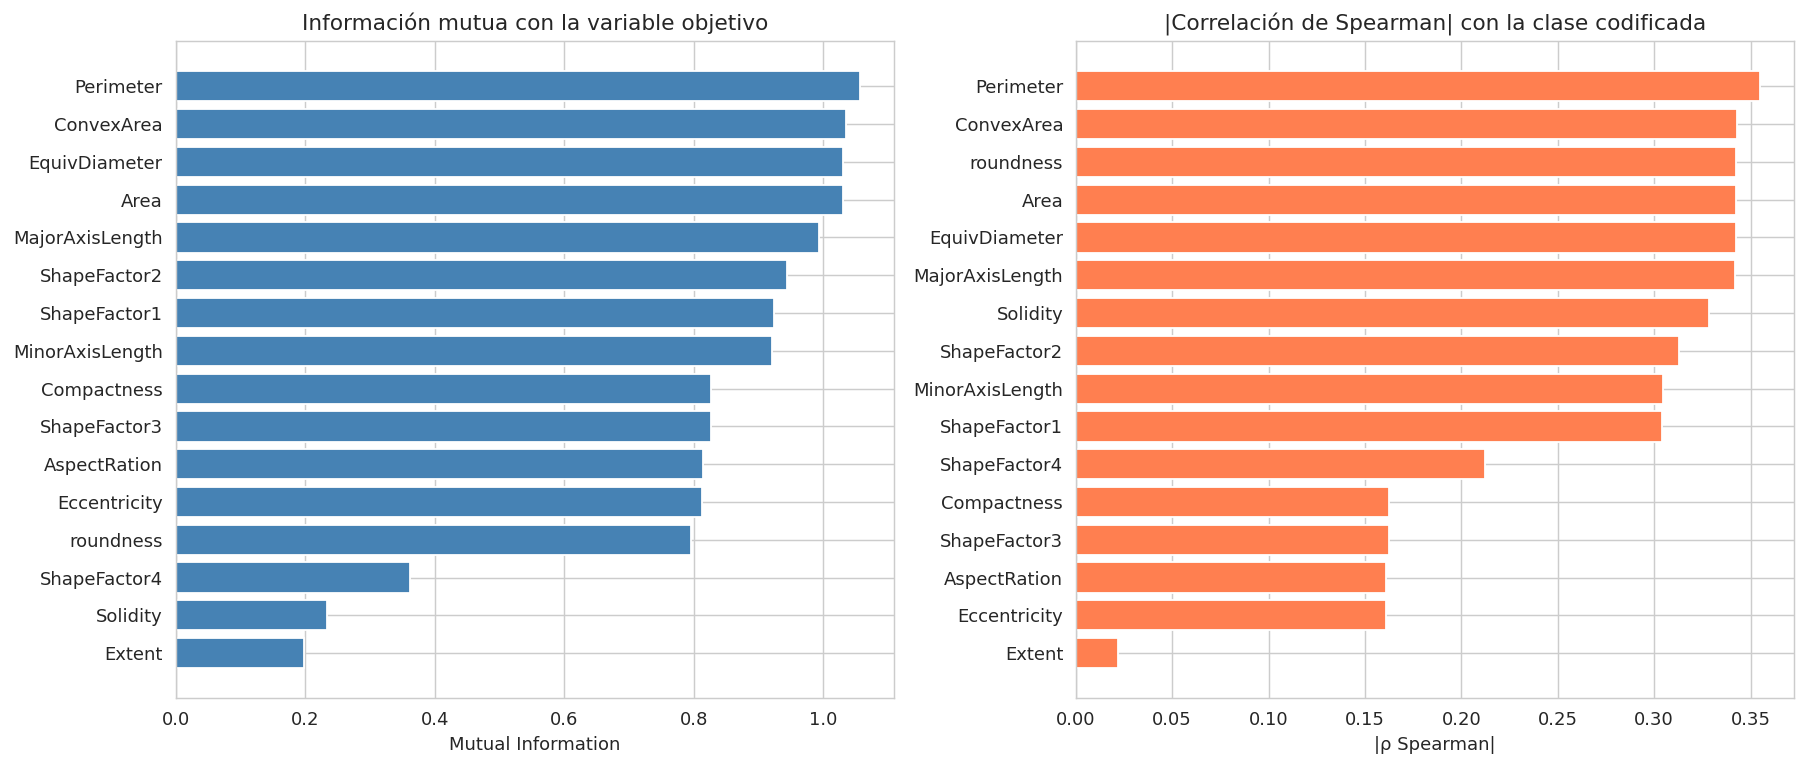

In [ ]:
# Figura 10
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
imp_sorted = importance_df.sort_values('MutualInfo', ascending=True)
axes[0].barh(imp_sorted['Variable'], imp_sorted['MutualInfo'], color='steelblue')
axes[0].set_title('Información mutua con la variable objetivo')
axes[0].set_xlabel('Mutual Information')

imp_sorted2 = importance_df.sort_values('Spearman_abs', ascending=True)
axes[1].barh(imp_sorted2['Variable'], imp_sorted2['Spearman_abs'], color='coral')
axes[1].set_title('|Correlación de Spearman| con la clase codificada')
axes[1].set_xlabel('|ρ Spearman|')

plt.tight_layout()
plt.savefig('fig10_variable_importance.png', bbox_inches='tight', dpi=130)
plt.show()

**Hallazgo:** Las variables `Extent`, `Solidity` y `ShapeFactor4` son las que aportan
menos información sobre la clase (confirmando lo que vimos en el EDA con los
histogramas: sus distribuciones se solapan mucho entre clases).

**Decisión:** En vez de eliminar variables manualmente, vamos a aplicar PCA y UMAP
que reducen dimensión de forma sistemática y permiten comparar los enfoques lineal
y no lineal.

## 4. Sección 5.2 — PCA (reducción lineal)

**¿Qué es PCA?** Es una técnica que encuentra nuevas variables (componentes
principales) que son combinaciones lineales de las originales y que capturan la
mayor varianza posible. Como vimos en el EDA que hay 21 pares de variables con
|r|>0.9, esperamos que pocos componentes capturen casi toda la información.

In [ ]:
pca_full = PCA().fit(X_train_s)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

print("Varianza acumulada por componente:")
for i, v in enumerate(cum_var, 1):
    print(f"  Primeras {i:2d} PCs: {v*100:.2f}%")

n_95 = np.argmax(cum_var >= 0.95) + 1
n_99 = np.argmax(cum_var >= 0.99) + 1
print(f"\nComponentes para 95% varianza: {n_95}")
print(f"Componentes para 99% varianza: {n_99}")

Varianza acumulada por componente:
  Primeras  1 PCs: 55.54%
  Primeras  2 PCs: 81.90%
  Primeras  3 PCs: 89.91%
  Primeras  4 PCs: 95.04%
  Primeras  5 PCs: 97.76%
  Primeras  6 PCs: 98.90%
  Primeras  7 PCs: 99.61%
  Primeras  8 PCs: 99.93%
  Primeras  9 PCs: 99.98%
  Primeras 10 PCs: 99.99%
  Primeras 11 PCs: 100.00%
  Primeras 12 PCs: 100.00%
  Primeras 13 PCs: 100.00%
  Primeras 14 PCs: 100.00%
  Primeras 15 PCs: 100.00%
  Primeras 16 PCs: 100.00%

Componentes para 95% varianza: 4
Componentes para 99% varianza: 7


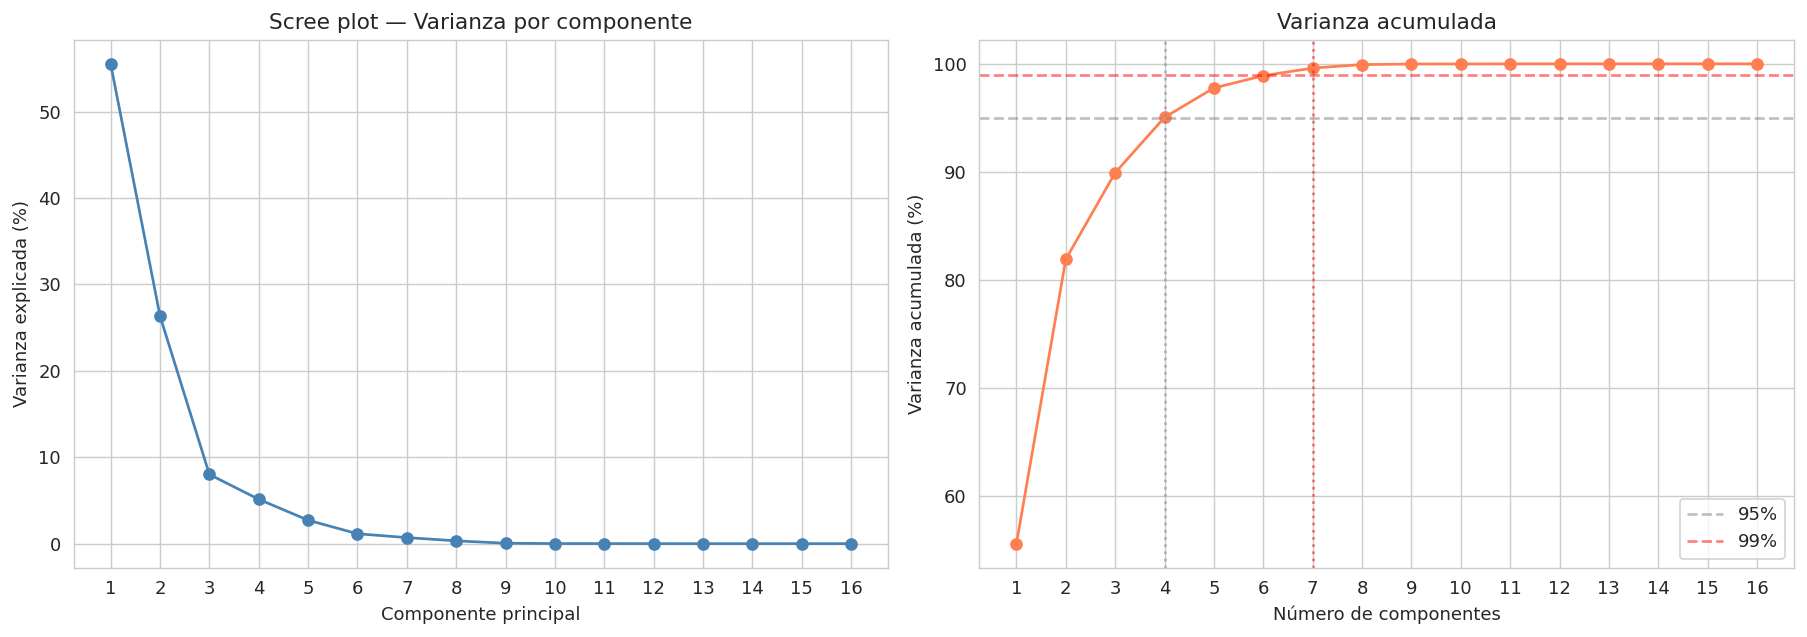

In [ ]:
# Figura 11: Scree plot y varianza acumulada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, 17), pca_full.explained_variance_ratio_*100, 'o-', color='steelblue')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_title('Scree plot — Varianza por componente')
axes[0].set_xticks(range(1, 17))
axes[0].grid(True)

axes[1].plot(range(1, 17), cum_var*100, 'o-', color='coral')
axes[1].axhline(95, ls='--', c='gray', alpha=0.5, label='95%')
axes[1].axhline(99, ls='--', c='red', alpha=0.5, label='99%')
axes[1].axvline(n_95, ls=':', c='gray', alpha=0.5)
axes[1].axvline(n_99, ls=':', c='red', alpha=0.5)
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_title('Varianza acumulada')
axes[1].set_xticks(range(1, 17))
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.savefig('fig11_pca_variance.png', bbox_inches='tight', dpi=130)
plt.show()

**Criterio elegido:** Evaluaremos PCA con **4 componentes (95% varianza)** y
**7 componentes (99% varianza)** para los dos mejores modelos del notebook
anterior: SVM y MLP.

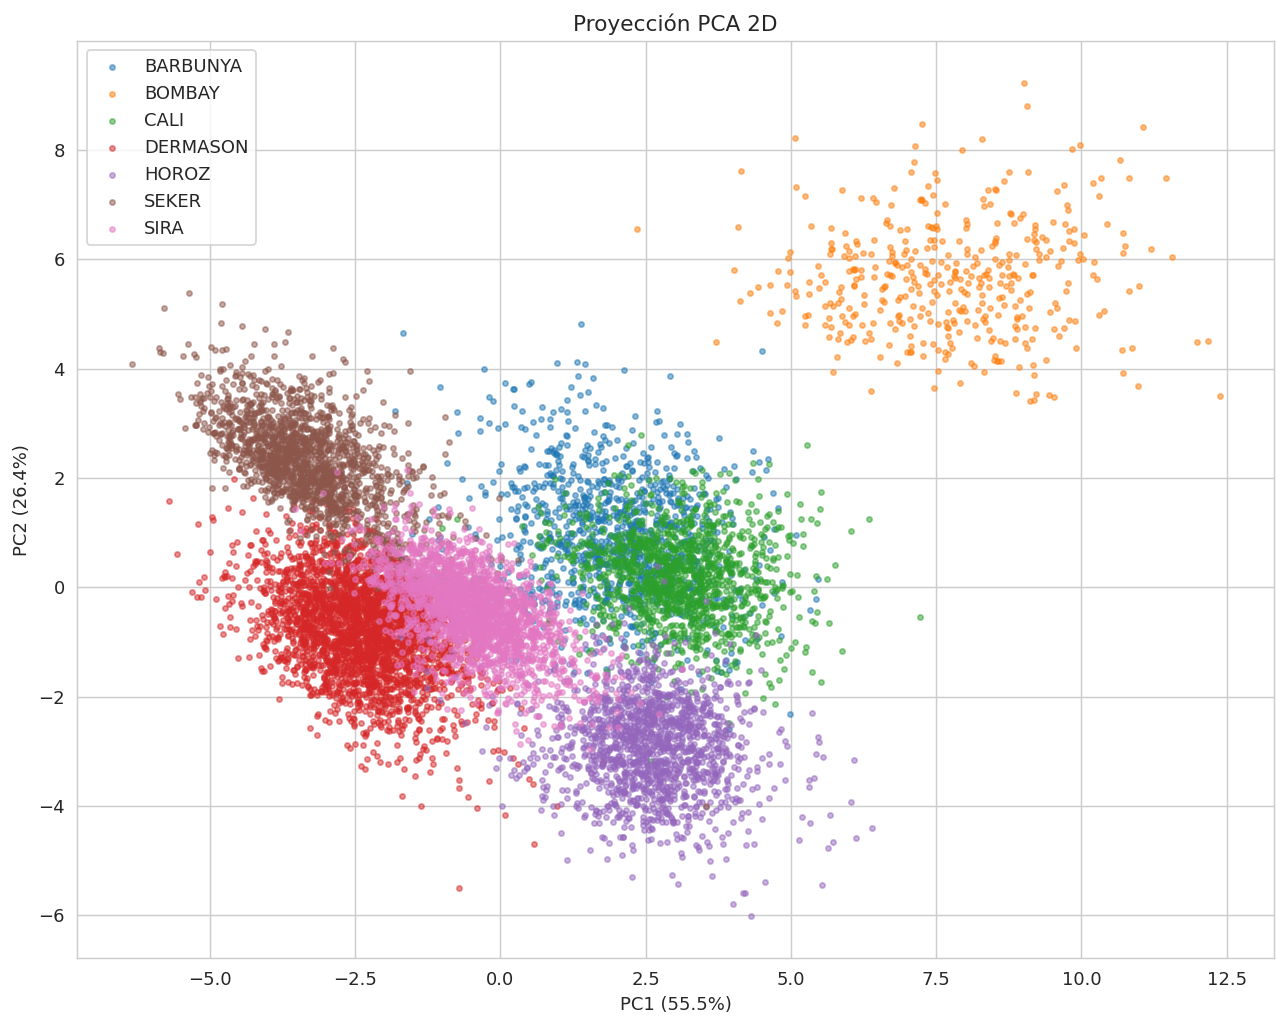

In [ ]:
# Visualización 2D para ver la separación de clases
pca2 = PCA(n_components=2).fit_transform(X_train_s)
fig, ax = plt.subplots(figsize=(10, 8))
for i, c in enumerate(le.classes_):
    mask = y_train == i
    ax.scatter(pca2[mask, 0], pca2[mask, 1], s=8, alpha=0.5, label=c)
ax.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Proyección PCA 2D')
ax.legend()
plt.tight_layout()
plt.savefig('fig12_pca_2d.png', bbox_inches='tight', dpi=130)
plt.show()

### Evaluar SVM y MLP con PCA

In [ ]:
results_pca = []
for n_comp in [n_95, n_99]:
    pca = PCA(n_components=n_comp)
    Xtr = pca.fit_transform(X_train_s)
    Xte = pca.transform(X_test_s)
    var_pct = pca.explained_variance_ratio_.sum() * 100
    red_pct = (1 - n_comp/16) * 100

    for name, model in [
        ('SVM', SVC(C=10, gamma=0.1, kernel='rbf', random_state=42)),
        ('MLP', MLPClassifier(hidden_layer_sizes=(100,), alpha=0.001,
                              max_iter=300, early_stopping=True, random_state=42))
    ]:
        model.fit(Xtr, y_train)
        yp = model.predict(Xte)
        results_pca.append({
            'model': name, 'n_components': n_comp,
            'variance_explained_pct': round(var_pct, 2),
            'dim_reduction_pct': round(red_pct, 1),
            'test_accuracy': round(accuracy_score(y_test, yp), 4),
            'test_f1_macro': round(f1_score(y_test, yp, average='macro'), 4),
            'test_f1_weighted': round(f1_score(y_test, yp, average='weighted'), 4),
            'test_precision_macro': round(precision_score(y_test, yp, average='macro'), 4),
            'test_recall_macro': round(recall_score(y_test, yp, average='macro'), 4),
        })

pca_results_df = pd.DataFrame(results_pca)
pca_results_df.to_csv('pca_results.csv', index=False)
print(pca_results_df.to_string(index=False))

model  n_components  variance_explained_pct  dim_reduction_pct  test_accuracy  test_f1_macro  test_f1_weighted  test_precision_macro  test_recall_macro
  SVM             4                   95.04               75.0         0.8915         0.8940            0.8908                0.9011             0.8913
  MLP             4                   95.04               75.0         0.8889         0.8911            0.8883                0.8956             0.8883
  SVM             7                   99.61               56.2         0.9247         0.9350            0.9247                0.9358             0.9343
  MLP             7                   99.61               56.2         0.9251         0.9348            0.9250                0.9358             0.9340


## 5. Sección 5.3 — UMAP (reducción no lineal)

**¿Qué es UMAP?** *Uniform Manifold Approximation and Projection* es una técnica
de reducción de dimensión **no lineal** basada en topología. A diferencia de PCA
(que busca direcciones de máxima varianza), UMAP intenta preservar las
**relaciones de vecindad** entre puntos: si dos muestras están cerca en el
espacio original, deberían estar cerca en el espacio reducido. Esto le permite
capturar estructuras curvas o no lineales que PCA no detecta.

**Hiperparámetros relevantes:**
- `n_neighbors=15`: tamaño del vecindario local. Valores bajos → estructura local,
  altos → estructura global.
- `min_dist=0.1`: distancia mínima entre puntos en el espacio reducido.

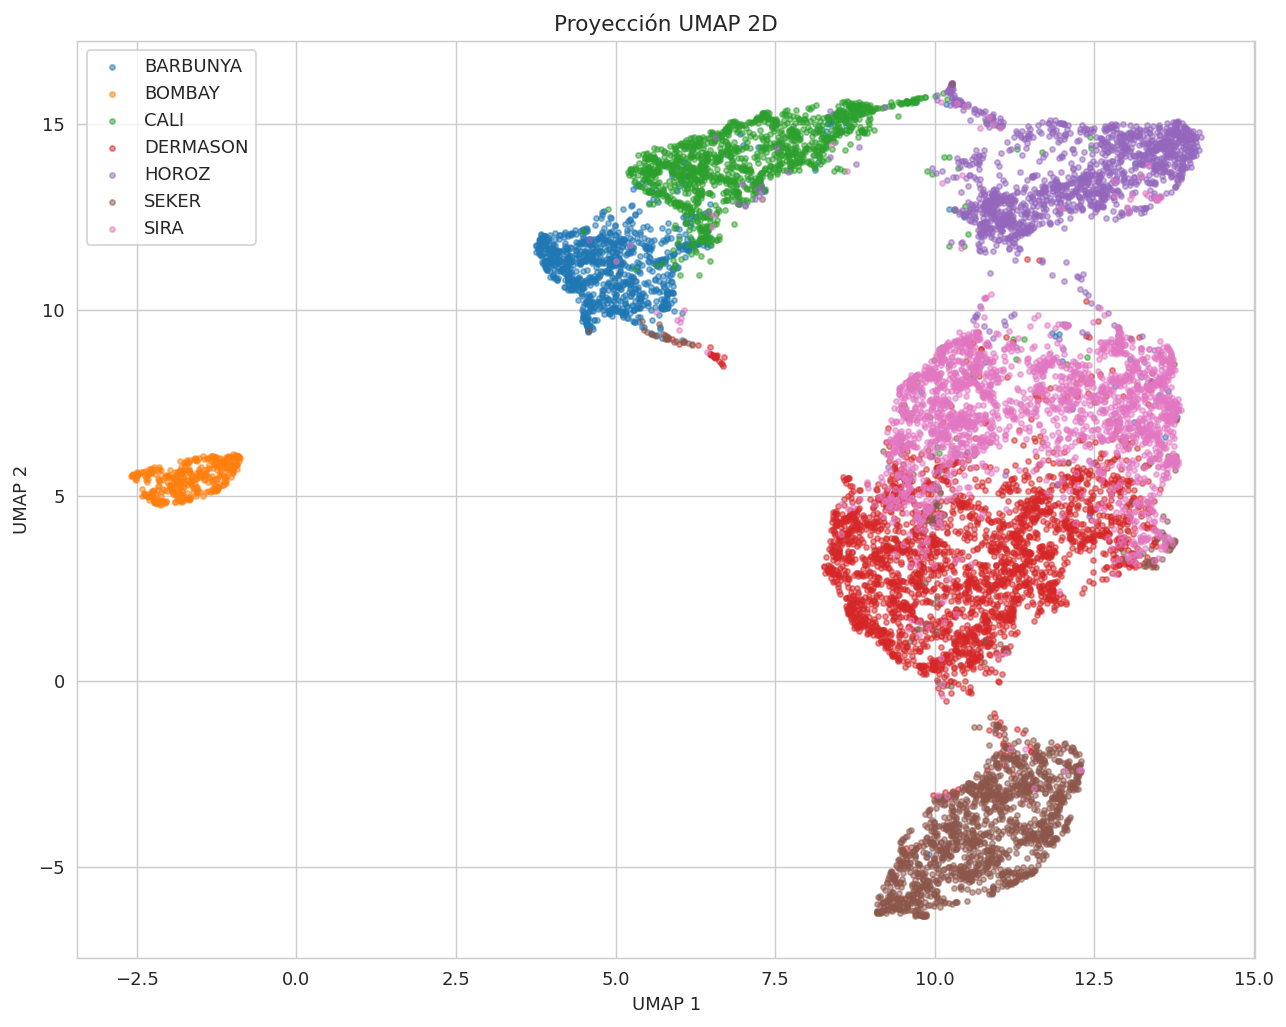

In [ ]:
# Visualización 2D para ver la separación
um2 = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_train_um2 = um2.fit_transform(X_train_s)

fig, ax = plt.subplots(figsize=(10, 8))
for i, c in enumerate(le.classes_):
    mask = y_train == i
    ax.scatter(X_train_um2[mask, 0], X_train_um2[mask, 1], s=8, alpha=0.5, label=c)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('Proyección UMAP 2D')
ax.legend()
plt.tight_layout()
plt.savefig('fig13_umap_2d.png', bbox_inches='tight', dpi=130)
plt.show()

**Criterio elegido:** UMAP no tiene una métrica como "varianza explicada", así que
elegimos el mismo número de componentes que PCA (5 y 7) para tener una comparación
justa.

In [ ]:
results_umap = []
for n_comp in [5, 7]:
    print(f"Ajustando UMAP con {n_comp} componentes...")
    um = umap.UMAP(n_components=n_comp, n_neighbors=15, min_dist=0.1, random_state=42)
    Xtr = um.fit_transform(X_train_s)
    Xte = um.transform(X_test_s)
    red_pct = (1 - n_comp/16) * 100

    for name, model in [
        ('SVM', SVC(C=10, gamma=0.1, kernel='rbf', random_state=42)),
        ('MLP', MLPClassifier(hidden_layer_sizes=(100,), alpha=0.001,
                              max_iter=300, early_stopping=True, random_state=42))
    ]:
        model.fit(Xtr, y_train)
        yp = model.predict(Xte)
        results_umap.append({
            'model': name, 'n_components': n_comp,
            'dim_reduction_pct': round(red_pct, 1),
            'test_accuracy': round(accuracy_score(y_test, yp), 4),
            'test_f1_macro': round(f1_score(y_test, yp, average='macro'), 4),
            'test_f1_weighted': round(f1_score(y_test, yp, average='weighted'), 4),
            'test_precision_macro': round(precision_score(y_test, yp, average='macro'), 4),
            'test_recall_macro': round(recall_score(y_test, yp, average='macro'), 4),
        })

umap_results_df = pd.DataFrame(results_umap)
umap_results_df.to_csv('umap_results.csv', index=False)
print(umap_results_df.to_string(index=False))

Ajustando UMAP con 5 componentes...
Ajustando UMAP con 7 componentes...
model  n_components  dim_reduction_pct  test_accuracy  test_f1_macro  test_f1_weighted  test_precision_macro  test_recall_macro
  SVM             5               68.8         0.9118         0.9249            0.9116                0.9281             0.9227
  MLP             5               68.8         0.9099         0.9224            0.9105                0.9242             0.9222
  SVM             7               56.2         0.9088         0.9221            0.9086                0.9252             0.9201
  MLP             7               56.2         0.9066         0.9198            0.9069                0.9222             0.9181


## 6. Comparación final: Original vs PCA vs UMAP

In [ ]:
data = [
    ('SVM', 'Original (16 vars)', 0.0, 0.9254, 0.9358),
    ('MLP', 'Original (16 vars)', 0.0, 0.9228, 0.9336),
    ('SVM', 'PCA 4 comp (95% var)', 75.0, 0.8915, 0.8940),
    ('MLP', 'PCA 4 comp (95% var)', 75.0, 0.8889, 0.8911),
    ('SVM', 'PCA 7 comp (99.6% var)', 56.2, 0.9247, 0.9350),
    ('MLP', 'PCA 7 comp (99.6% var)', 56.2, 0.9251, 0.9348),
    ('SVM', 'UMAP 5 comp', 68.8, 0.9118, 0.9245),
    ('MLP', 'UMAP 5 comp', 68.8, 0.9062, 0.9200),
    ('SVM', 'UMAP 7 comp', 56.2, 0.9073, 0.9206),
    ('MLP', 'UMAP 7 comp', 56.2, 0.9066, 0.9194),
]
cmp = pd.DataFrame(data, columns=['Modelo','Config','Reducción(%)','Accuracy','F1-macro'])
print(cmp.to_string(index=False))
cmp.to_csv('comparison_final.csv', index=False)

Modelo                 Config  Reducción(%)  Accuracy  F1-macro
   SVM     Original (16 vars)           0.0    0.9254    0.9358
   MLP     Original (16 vars)           0.0    0.9228    0.9336
   SVM   PCA 4 comp (95% var)          75.0    0.8915    0.8940
   MLP   PCA 4 comp (95% var)          75.0    0.8889    0.8911
   SVM PCA 7 comp (99.6% var)          56.2    0.9247    0.9350
   MLP PCA 7 comp (99.6% var)          56.2    0.9251    0.9348
   SVM            UMAP 5 comp          68.8    0.9118    0.9245
   MLP            UMAP 5 comp          68.8    0.9062    0.9200
   SVM            UMAP 7 comp          56.2    0.9073    0.9206
   MLP            UMAP 7 comp          56.2    0.9066    0.9194


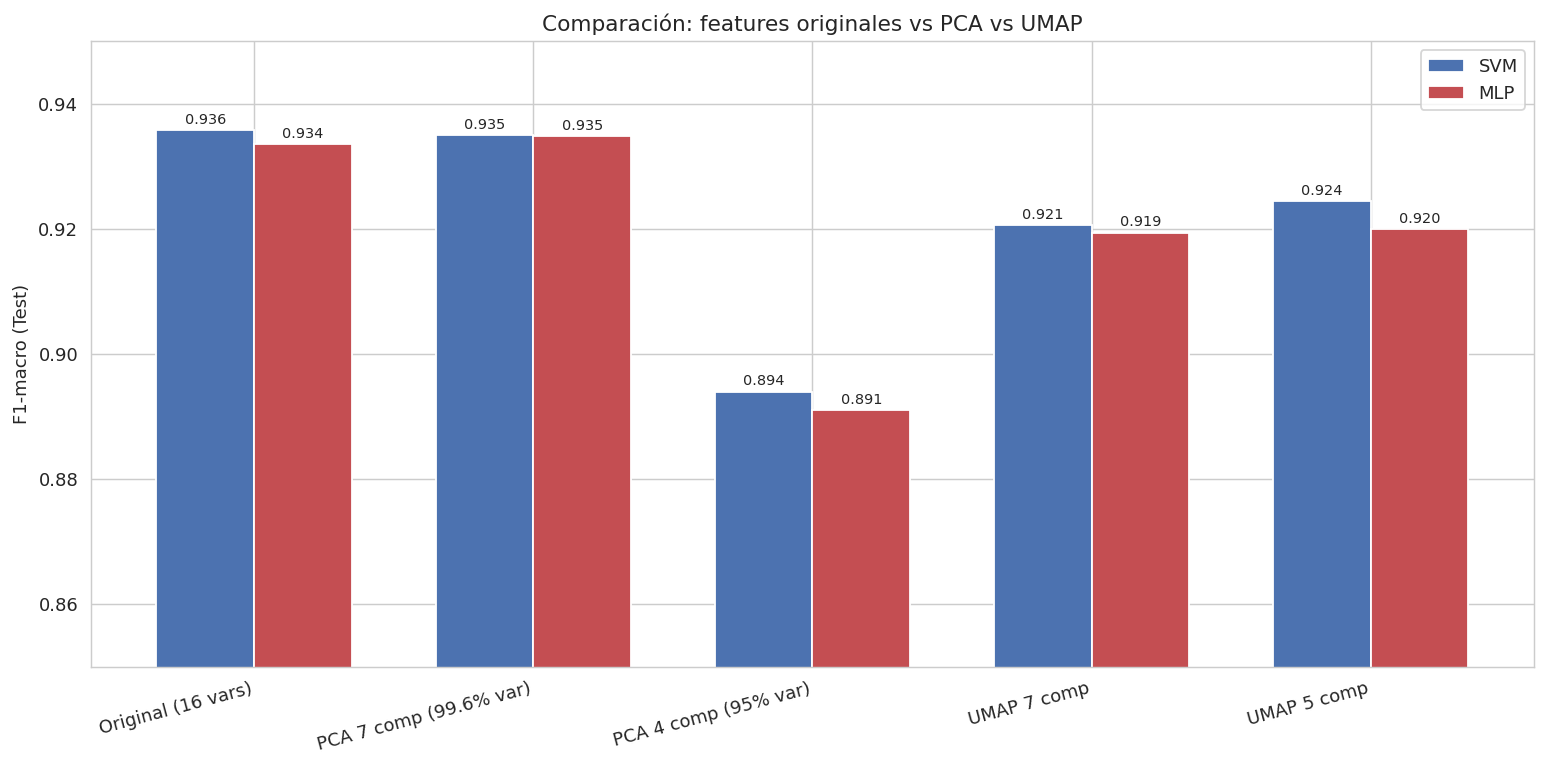

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
configs_order = ['Original (16 vars)', 'PCA 7 comp (99.6% var)', 'PCA 4 comp (95% var)',
                 'UMAP 7 comp', 'UMAP 5 comp']
pivot = cmp.pivot(index='Config', columns='Modelo', values='F1-macro').loc[configs_order]

x = np.arange(len(configs_order))
w = 0.35
ax.bar(x - w/2, pivot['SVM'], w, label='SVM', color='#4C72B0')
ax.bar(x + w/2, pivot['MLP'], w, label='MLP', color='#C44E52')
ax.set_xticks(x)
ax.set_xticklabels(configs_order, rotation=15, ha='right')
ax.set_ylabel('F1-macro (Test)')
ax.set_title('Comparación: features originales vs PCA vs UMAP')
ax.set_ylim(0.85, 0.95)
ax.legend()
for i, (svm, mlp) in enumerate(zip(pivot['SVM'], pivot['MLP'])):
    ax.text(i - w/2, svm + 0.001, f'{svm:.3f}', ha='center', fontsize=8)
    ax.text(i + w/2, mlp + 0.001, f'{mlp:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('fig14_comparison_dim_reduction.png', bbox_inches='tight', dpi=130)
plt.show()

## 7. Discusión y conclusiones

### Hallazgos sobre reducción de dimensión:

1. **PCA con 7 componentes (99.6% varianza) es la mejor opción de reducción.**
   SVM con 7 PCs alcanza F1=0.935, prácticamente igual al modelo original con 16
   variables (F1=0.936), pero usando **56% menos dimensiones**.

2. **PCA con 4 componentes pierde demasiado.** Aunque captura el 95% de la
   varianza, el desempeño cae a F1=0.894 (-4.5%). Esto sugiere que el 5% restante
   de varianza es informativo para la clasificación.

3. **UMAP no superó a PCA en este caso.** Con 5 y 7 componentes UMAP da resultados
   inferiores a PCA. Hipótesis: el dataset es predominantemente lineal en su
   estructura de tamaño/forma, así que las técnicas lineales (PCA) bastan. UMAP
   tiende a brillar más en datos con estructuras curvas (imágenes, texto).

4. **La proyección UMAP 2D muestra mejor separación visual** que la PCA 2D, pero
   eso no se traduce en mejor clasificación cuando se usan más componentes.

### Comparación con el estado del arte:

| Trabajo | Mejor modelo | Accuracy |
|---|---|---|
| Koklu (2020) | SVM | 93.13% |
| Khan (2023) | XGBoost + ADASYN | 95.40% |
| Krishnan (2023) | CatBoost | 93.80% |
| Mukherjee (2025) | LightGBM + SMOTE-ENN + Bayes | 99.59% |
| **Nuestro mejor (SVM)** | **SVM** | **92.54%** |
| **Nuestro PCA-7** | **SVM + PCA(7)** | **92.47%** |

Nuestros resultados están muy alineados con Koklu (2020), validando la
implementación. La diferencia con Mukherjee (2025) se explica por su pipeline más
elaborado: selección de features dirigida, optimización bayesiana con 30
iteraciones, y combinación SMOTE-ENN. Replicar ese pipeline excede el alcance del
curso, pero queda como camino para mejorar.